# Final Project

## 1. Scope the Project

Our plan is to use a supervised learning technique to predict which customers are most likely to cancel their subscription using **the past three months of customer data which includes subscription and listening history**.

우리의 계획은 지도 학습 기법을 사용하여 구독 및 청취 이력이 포함된 최근 3개월 고객 데이터를 활용해 어떤 고객이 구독을 취소할 가능성이 가장 높은지 예측하는 것입니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Gather Data

Read the following files into Python:
* Customer data: *maven_music_customers.csv*
* Listing history: *maven_music_listening_history.xlsx*

다음 파일들을 Python으로 읽어오세요:
* 고객 데이터: maven_music_customers.csv
* 청취 이력: maven_music_listening_history.xlsx

In [2]:
# Read in the customer data
df_customer = pd.read_csv('../Data/maven_music_customers.csv')
df_customer.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [3]:
# Read in the listening history
df_history = pd.read_excel('../Data/maven_music_listening_history.xlsx', sheet_name='listening_history')
df_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [4]:
# Hint: Where might you find listening history data beyond the ID's?


In [5]:
# Read in the audio data
df_audio = pd.read_excel('../Data/maven_music_listening_history.xlsx', sheet_name='audio_files')
df_audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [6]:
# Read in the session data
df_session = pd.read_excel('../Data/maven_music_listening_history.xlsx', sheet_name='session_login_time')
df_session.head()

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


## 3. Clean Data

### a. Convert Data Types

Check the data types of the data in the tables and convert to numeric and datetime values as necessary.


테이블의 데이터 타입을 확인하고 필요에 따라 숫자형 및 날짜/시간 값으로 변환하세요

In [7]:
# Check the data types
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer ID        30 non-null     int64 
 1   Customer Name      30 non-null     object
 2   Email              30 non-null     object
 3   Member Since       30 non-null     object
 4   Subscription Plan  25 non-null     object
 5   Subscription Rate  30 non-null     object
 6   Discount?          7 non-null      object
 7   Cancellation Date  13 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.0+ KB


In [8]:
# df_customer['Subscription Rate'].value_counts()
df_customer['Subscription Rate'] = df_customer['Subscription Rate'].str.replace('$', '').astype(float)
df_customer.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,2.99,NaN,NaN


In [9]:
# Member Since 값 확인
# df_customer['Member Since'].value_counts()
df_customer['Member Since'] = pd.to_datetime(df_customer['Member Since'], format='%m/%d/%y')

In [10]:
df_customer['Cancellation Date'] = pd.to_datetime(df_customer['Cancellation Date'], format='%m/%d/%y')

In [11]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  25 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          7 non-null      object        
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 2.0+ KB


In [12]:
# Convert objects to numeric and datetime fields
df_history['Audio Type'].value_counts()

Audio Type
Song       463
Podcast     42
Name: count, dtype: int64

In [13]:
# df_audio.info()
df_audio['Genre'].value_counts()

Genre
Pop Music     3
Comedy        3
Hip Hop       3
Country       2
Pop           2
Jazz          2
True Crime    2
Name: count, dtype: int64

In [14]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Session ID           90 non-null     int64         
 1   Session Log In Time  90 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.5 KB


### b. Resolve Data Issues

Check for missing data, inconsistent text and typos, duplicate data and outliers.

결측 데이터, 일관성 없는 텍스트 및 오타, 중복 데이터, 이상치를 확인하세요.

#### i. Missing Data

In [16]:
# Look for NaN values in the data
df_customer.isna().sum()

Customer ID           0
Customer Name         0
Email                 0
Member Since          0
Subscription Plan     5
Subscription Rate     0
Discount?            23
Cancellation Date    17
dtype: int64

In [17]:
df_customer.info()
# 결측치 : Subscription Plan, Discount?, Cancellation Date

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  25 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          7 non-null      object        
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 2.0+ KB


In [18]:
df_customer['Subscription Plan'].value_counts(dropna=False)

Subscription Plan
Premium (No Ads)    13
Basic (Ads)         12
NaN                  5
Name: count, dtype: int64

In [19]:
df_customer['Subscription Rate'].value_counts(dropna=False)

Subscription Rate
2.99     17
7.99      7
9.99      5
99.99     1
Name: count, dtype: int64

In [20]:
df_customer[['Subscription Plan', 'Subscription Rate', 'Discount?']]

,Subscription Plan,Subscription Rate,Discount?
0,Basic (Ads),2.99,NaN
1,NaN,2.99,NaN
2,NaN,2.99,NaN
3,Basic (Ads),2.99,NaN
4,NaN,2.99,NaN
5,NaN,2.99,NaN
6,Premium (No Ads),9.99,NaN
7,Premium (No Ads),9.99,NaN
8,Premium (No Ads),9.99,NaN
9,Basic (Ads),2.99,NaN


In [21]:
# fillna 로 결측치 제거
df_customer['Subscription Plan'] = df_customer['Subscription Plan'].fillna('Basic (Ads)')
df_customer['Discount?'] = df_customer['Discount?'].fillna(0)
df_customer['Discount?'] = df_customer['Discount?'].replace('Yes', 1)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30764\4159927638.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_customer['Discount?'] = df_customer['Discount?'].replace('Yes', 1)


In [22]:
# 이상치 제거 99.99 -> 9.99
df_customer['Subscription Rate'] = df_customer['Subscription Rate'].replace(99.99, 9.99)
df_customer['Subscription Rate'].value_counts()

Subscription Rate
2.99    17
7.99     7
9.99     6
Name: count, dtype: int64

#### ii. Inconsistent Text & Typos

In [23]:
# Look for inconsistent text & typos
# 일관성없는 텍스트 및 오타 찾기
# df_customer['Subscription Plan'].value_counts()
# df_audio['Genre'].value_counts()
# df_history['Audio Type'].value_counts()
df_audio['Genre'] = df_audio['Genre'].str.replace('Pop Music', 'Pop')

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
Name: Subscription Plan, dtype: bool

#### iii. Duplicate Rows

In [24]:
# Look for duplicate rows
# 중복 행 개수 확인
print(df_customer.duplicated().sum())
print(df_history.duplicated().sum())
print(df_audio.duplicated().sum())
print(df_session.duplicated().sum())

0
0
0
0


In [45]:
df_customer[df_customer.duplicated(subset=['Customer ID'], keep=False)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Member Date


In [ ]:
# 중복데이터 제거
df_customer[df_customer.duplicated()]
df_history[df_history.duplicated()]
df_audio[df_audio.duplicated()]
df_session[df_session.duplicated()]

#### iv. Outliers

In [46]:
# Look for outliers
df_customer.describe()

,Customer ID,Member Since,Subscription Rate,Discount?,Cancellation Date,Cancelled,Member Date
count,30.000000,30,30.000000,30.000000,13,30.000000,13.000000
mean,6276.333333,2023-04-10 06:24:00,5.556667,0.233333,2023-06-01 16:36:55.384615424,0.433333,46.307692
min,5001.000000,2023-03-13 00:00:00,2.990000,0.000000,2023-06-01 00:00:00,0.000000,16.000000
25%,5759.500000,2023-03-23 12:00:00,2.990000,0.000000,2023-06-01 00:00:00,0.000000,24.000000
50%,6196.000000,2023-04-05 12:00:00,2.990000,0.000000,2023-06-02 00:00:00,0.000000,46.000000
75%,6823.500000,2023-05-01 00:00:00,7.990000,0.000000,2023-06-02 00:00:00,1.000000,65.000000
max,7583.000000,2023-05-16 00:00:00,9.990000,1.000000,2023-06-03 00:00:00,1.000000,80.000000
std,814.255587,NaN,3.058998,0.430183,NaN,0.504007,23.135055


In [47]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  30 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          30 non-null     int64         
 7   Cancellation Date  13 non-null     datetime64[ns]
 8   Cancelled          30 non-null     int64         
 9   Member Date        13 non-null     float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 2.5+ KB


### c. Create New Columns

Create two new columns that will be useful for EDA and modeling:
* Cancelled: whether a customer cancelled or not
* Email: Remove the "Email:" from the email addresses

EDA와 모델링에 유용할 두 개의 새 컬럼을 생성하세요:
* Cancelled: 고객의 구독 취소 여부
* Email: 이메일 주소에서 "Email:" 부분을 제거

In [27]:
# Create a 'Cancelled' column
df_customer.Email.value_counts()
df_customer.Email = df_customer.Email.str.replace('Email:', '')

In [28]:
df_customer.Email.value_counts()

Email
harmonious.vibes@email.com      1
melodious.aria@email.edu        1
rhythmical.lyric@email.com      1
groovy.rock@email.com           1
beats.by.rhythm@email.edu       1
jazzy.sax@email.com             1
sharp.tunes@email.com           1
songbird.carol@email.com        1
musical.sonata@email.com        1
coleman.jazzmaster@email.com    1
harmonic.chord@email.com        1
rhythmic.franklin@email.edu     1
campbell.chordify@email.com     1
rhythmic.benny@email.com        1
park.of.melodies@email.com      1
rhodes.symphony@email.com       1
beats.by.beatrice@email.com     1
bass.master.bobby@email.edu     1
lyrical.saunders@email.edu      1
bass.harmony@email.com          1
flat.tunes@email.edu            1
kiki.keys.piano@email.com       1
groovy.greta@email.com          1
heartfelt.harmony@email.com     1
wallace.harmony@email.com       1
fitzgerald.melody@email.com     1
murphy.reed.music@email.com     1
drumming.jazz@email.com         1
keysoflyric@email.com           1
melodic.

In [29]:
# Create an updated 'Email' column without the Email: portion
df_customer.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [30]:
# notna() : 결측치면 False, 결측치가 아니면 True
df_customer['Cancelled'] = df_customer['Cancellation Date'].notna().astype(int)
df_customer.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


## 4. EDA

Try to better understand the customers who cancelled:
* How long were they members before they cancelled?
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?

구독을 취소한 고객을 더 잘 이해해보세요:
* 취소 전에 얼마나 오래 회원이었나요?
* 취소한 고객 중 할인을 받은 고객의 비율 vs 취소하지 않은 고객의 비율은?

In [48]:
# 취소한 고객들을 더 잘 이해하려는 것이 목표
# How long were customers members before they cancelled?
df_customer.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Member Date
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0,NaN
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0,NaN
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1,80.0
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0,NaN
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0,NaN


In [49]:
df_customer[df_customer['Cancellation Date'].notna()].head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Member Date
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1,80.0
5,5404,Jazz Saxton,jazzy.sax@email.com,2023-03-20,Basic (Ads),2.99,0,2023-06-03,1,75.0
7,5759,Carol Kingbird,songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02,1,72.0
12,6029,Chord Campbell,campbell.chordify@email.com,2023-03-29,Premium (No Ads),9.99,0,2023-06-02,1,65.0
13,6092,Benny Beat,rhythmic.benny@email.com,2023-04-01,Basic (Ads),2.99,0,2023-06-01,1,61.0


In [50]:
(df_customer['Cancellation Date'] - df_customer['Member Since']).mean()

Timedelta('46 days 07:23:04.615384615')

In [54]:
# Cancellation rate for those who had a discount
discount_yes = df_customer[df_customer['Discount?'] == 1]
discount_no = df_customer[df_customer['Discount?'] == 0]
discount_yes

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Member Date
21,6822,Kiki Keys,kiki.keys.piano@email.com,2023-05-01,Premium (No Ads),7.99,1,NaT,0,NaN
22,6824,Greta Groove,groovy.greta@email.com,2023-05-01,Premium (No Ads),7.99,1,2023-06-02,1,32.0
23,7087,Harmony Heart,heartfelt.harmony@email.com,2023-05-01,Premium (No Ads),7.99,1,2023-06-02,1,32.0
25,7224,Melody Fitzgerald,fitzgerald.melody@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01,1,24.0
26,7401,Reed Murphy,murphy.reed.music@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01,1,24.0
28,7581,Lyric Keys,keysoflyric@email.com,2023-05-16,Premium (No Ads),7.99,1,2023-06-03,1,18.0
29,7583,Melody Singer,melodic.singer@email.com,2023-05-16,Premium (No Ads),7.99,1,2023-06-01,1,16.0


In [58]:
# Cancellation rate for those who did not have a discount
# 할인을 받은 사람의 취소 비율이 85%
yes_cancellation_rate = discount_yes.Cancelled.sum() / discount_yes.Cancelled.count()

In [59]:
# 할인을 안받은 사람의 취소비율이 30%
no_cancellation_rate = discount_no.Cancelled.sum() / discount_no.Cancelled.count()

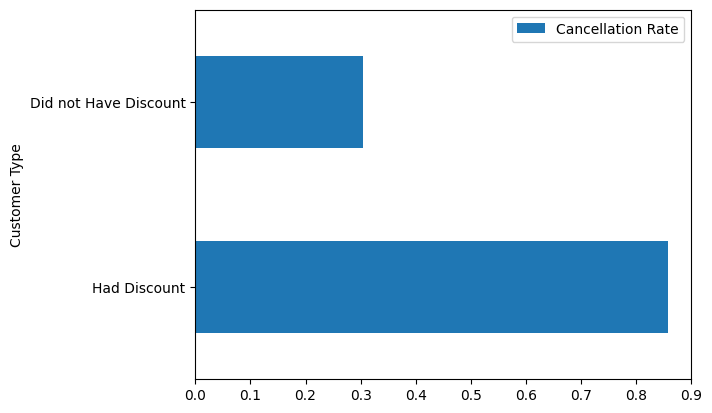

In [60]:
# Visualize the cancellation rate for those with a discount vs those without a discount
pd.DataFrame([['Had Discount', yes_cancellation_rate], 
['Did not Have Discount', no_cancellation_rate]], 
columns=['Customer Type', 'Cancellation Rate']).plot.barh(x='Customer Type', y= 'Cancellation Rate', );

Better understand the customers' listening histories:
* Join together the listening history and audio tables
* How many listening sessions did each customer have in the past 3 months?
* What were the most popular genres that customers listened to?

고객의 청취 이력을 더 잘 이해해보세요:
* 청취 이력 테이블과 오디오 테이블을 조인하세요
* 지난 3개월 동안 각 고객이 몇 번의 청취 세션을 가졌나요?
* 고객들이 가장 많이 들은 인기 장르는 무엇인가요?

In [61]:
df_customer.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled,Member Date
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0,NaN
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0,NaN
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1,80.0
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0,NaN
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0,NaN


In [62]:
df_audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop,5
3,Song-104,Glowing Hearts,Pop,10
4,Song-105,Pop Rocks,Pop,52


In [64]:
df_audio_clean = pd.DataFrame(df_audio.ID.str.split('-').to_list()).rename(columns={0:'Type', 1:'Audio ID'})
df_audio_clean.head()

,Type,Audio ID
0,Song,101
1,Song,102
2,Song,103
3,Song,104
4,Song,105


In [65]:
# Split the ID in the audio data so the column can be joined with other tables
df_audio_all = pd.concat([df_audio_clean, df_audio], axis=1)
df_audio_all.head()

,Type,Audio ID,ID,Name,Genre,Popularity
0,Song,101,Song-101,Dance All Night,Pop,1
1,Song,102,Song-102,Unbreakable Beat,Pop,2
2,Song,103,Song-103,Sunset Boulevard,Pop,5
3,Song,104,Song-104,Glowing Hearts,Pop,10
4,Song,105,Song-105,Pop Rocks,Pop,52


In [67]:
# df_audio_all.info() 
df_audio_all['Audio ID'] = df_audio_all['Audio ID'].astype('int')
df_audio_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Type        17 non-null     object
 1   Audio ID    17 non-null     int64 
 2   ID          17 non-null     object
 3   Name        17 non-null     object
 4   Genre       17 non-null     object
 5   Popularity  17 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 948.0+ bytes


In [36]:
# Hint: Check the data type of Audio ID in the audio table


In [68]:
# The number of listening sessions that each customer had in the past 3 months
df = df_history.merge(df_audio_all, how='left', on='Audio ID')
df

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52
...,...,...,...,...,...,...,...,...,...,...
500,7579,111282,4,111,Song,Song,Song-111,Moonlit Serenade,Jazz,63
501,6588,111286,1,201,Podcast,Podcast,Podcast-201,Jokes on Jokes,Comedy,2
502,5763,111333,1,110,Song,Song,Song-110,Boss Moves,Hip Hop,28
503,5763,111333,2,108,Song,Song,Song-108,Chase the Dream,Hip Hop,4


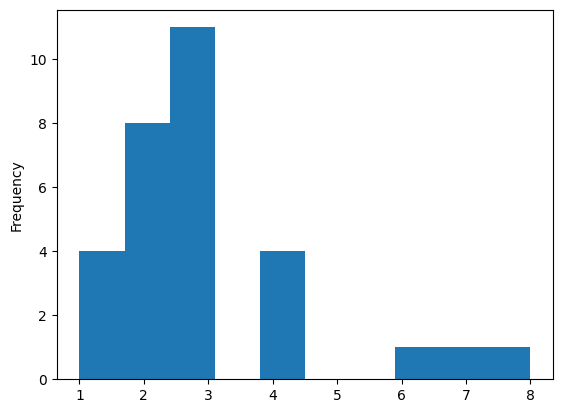

In [69]:
# The most popular genres that customers listened to
df.groupby('Customer ID')['Session ID'].nunique().plot.hist();

In [ ]:
df.Genre.value_counts()
# Pop

Genre
Pop           267
Hip Hop        88
Country        68
Jazz           48
Comedy         19
True Crime     15
Name: count, dtype: int64

## 5. Prep for Modeling

Create a DataFrame that is ready for modeling with each row representing a customer and the following numeric, non-null columns:
* Customer ID
* Whether a customer cancelled or not
* Whether a customer received a discount or not
* The number of listening sessions
* Percent of listening history consisting of Pop
* Percent of listening history consisting of Podcasts

각 행이 고객을 나타내고 다음과 같은 숫자형, null이 없는 컬럼들을 가진 모델링용 DataFrame을 생성하세요:
* Customer ID (고객 ID)
* 고객의 구독 취소 여부
* 고객의 할인 수령 여부
* 청취 세션 수
* 청취 이력 중 Pop 장르의 비율
* 청취 이력 중 Podcast의 비율

In [71]:
# Create a dataframe ready for modeling
model_df = df_customer[['Customer ID', 'Cancelled', 'Discount?']]
model_df.head()

,Customer ID,Cancelled,Discount?
0,5001,0,0
1,5002,0,0
2,5004,1,0
3,5267,0,0
4,5338,0,0


In [74]:
# Calculate the number of listening sessions for each customer
number_of_sessions = df.groupby('Customer ID')['Session ID'].nunique().rename('Number of Sessions').to_frame().reset_index()
number_of_sessions.head()

,Customer ID,Number of Sessions
0,5001,8
1,5002,4
2,5004,1
3,5267,7
4,5338,4


In [75]:
# Percent pop
model_df = model_df.merge(number_of_sessions, how='left', on='Customer ID')
model_df.head()

,Customer ID,Cancelled,Discount?,Number of Sessions
0,5001,0,0,8
1,5002,0,0,4
2,5004,1,0,1
3,5267,0,0,7
4,5338,0,0,4


In [77]:
# Percent podcasts
df.Genre

0          Pop
1          Pop
2          Pop
3          Pop
4          Pop
        ...   
500       Jazz
501     Comedy
502    Hip Hop
503    Hip Hop
504    Hip Hop
Name: Genre, Length: 505, dtype: object

Visualize the relationships in the modeling DataFrame using a pair plot:
* What are some of your observations?
* What variables might do a good job predicting customer cancellation?


페어 플롯(pair plot)을 사용하여 모델링 DataFrame의 관계를 시각화하세요:
* 어떤 관찰 결과가 있나요?
* 어떤 변수가 고객 취소를 예측하는 데 좋은 역할을 할 것 같나요?

In [81]:
pd.get_dummies(df.Genre, dtype=int)

,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0
...,...,...,...,...,...,...
500,0,0,0,1,0,0
501,1,0,0,0,0,0
502,0,0,1,0,0,0
503,0,0,1,0,0,0


In [83]:
pd.concat([df['Customer ID'], pd.get_dummies(df.Genre, dtype=int)], axis=1)

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,0,0,1,0
1,5001,0,0,0,0,1,0
2,5001,0,0,0,0,1,0
3,5001,0,0,0,0,1,0
4,5001,0,0,0,0,1,0
...,...,...,...,...,...,...,...
500,7579,0,0,0,1,0,0
501,6588,1,0,0,0,0,0
502,5763,0,0,1,0,0,0
503,5763,0,0,1,0,0,0


In [89]:
df_genres = pd.concat([df['Customer ID'], pd.get_dummies(df.Genre)], axis=1).groupby('Customer ID').sum().reset_index()
df_genres.head()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,26,0,34,0
1,5002,0,22,0,0,0,0
2,5004,0,0,0,0,9,0
3,5267,0,0,22,0,23,0
4,5338,0,18,0,0,0,0


In [86]:
df_history.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [88]:
df_total_audio = df_history.groupby('Customer ID')['Audio ID'].count().rename('Total Audio').to_frame().reset_index()
df_total_audio.head()

,Customer ID,Total Audio
0,5001,60
1,5002,22
2,5004,9
3,5267,45
4,5338,18


In [90]:
df_audio = df_genres.merge(df_total_audio, how='left', on='Customer ID')
df_audio

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Total Audio
0,5001,0,0,26,0,34,0,60
1,5002,0,22,0,0,0,0,22
2,5004,0,0,0,0,9,0,9
3,5267,0,0,22,0,23,0,45
4,5338,0,18,0,0,0,0,18
5,5404,0,0,0,0,8,0,8
6,5581,0,0,0,0,0,5,5
7,5759,0,0,0,0,15,0,15
8,5761,0,0,0,0,0,5,5
9,5763,0,0,11,0,20,0,31


In [91]:
model_df['Percent Pop'] = df_audio.Pop / df_audio['Total Audio'] * 100
model_df.head()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop
0,5001,0,0,8,56.666667
1,5002,0,0,4,0.000000
2,5004,1,0,1,100.000000
3,5267,0,0,7,51.111111
4,5338,0,0,4,0.000000


In [92]:
model_df['Percent Podcasts'] = ((df_audio['Comedy'] + df_audio['True Crime']) / df_audio['Total Audio']) * 100
model_df.head()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop,Percent Podcasts
0,5001,0,0,8,56.666667,0.0
1,5002,0,0,4,0.000000,0.0
2,5004,1,0,1,100.000000,0.0
3,5267,0,0,7,51.111111,0.0
4,5338,0,0,4,0.000000,0.0


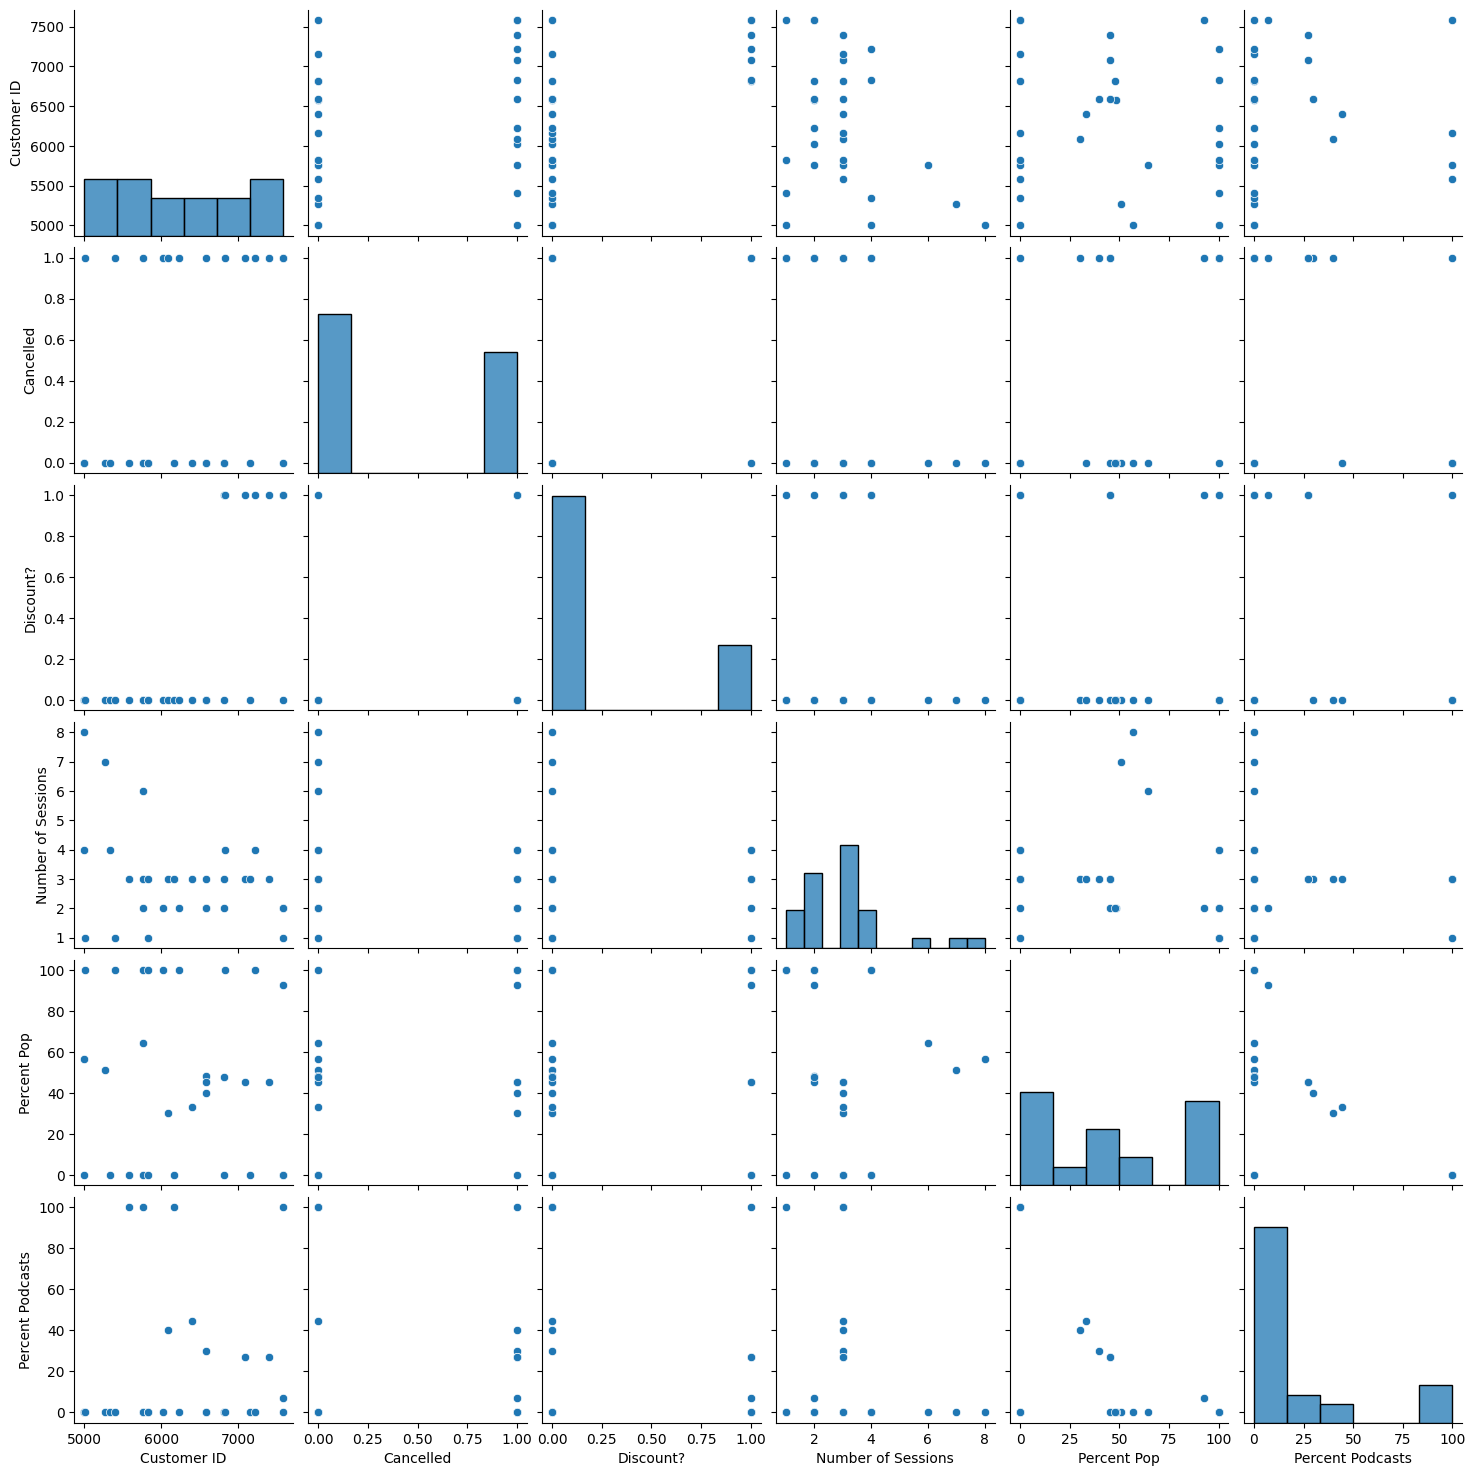

In [93]:
sns.pairplot(model_df)

In [94]:
# Look at the correlations
model_df.corr()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop,Percent Podcasts
Customer ID,1.000000,0.269942,0.648514,-0.337083,-0.076129,0.083083
Cancelled,0.269942,1.000000,0.471825,-0.333739,0.585630,-0.035414
Discount?,0.648514,0.471825,1.000000,-0.048877,0.112675,0.062938
Number of Sessions,-0.337083,-0.333739,-0.048877,1.000000,-0.131156,-0.125459
Percent Pop,-0.076129,0.585630,0.112675,-0.131156,1.000000,-0.487193
Percent Podcasts,0.083083,-0.035414,0.062938,-0.125459,-0.487193,1.000000


In [98]:
# model_df.corr()['Cancelled']
model_df.corr()[['Cancelled']]

,Cancelled
Customer ID,0.269942
Cancelled,1.000000
Discount?,0.471825
Number of Sessions,-0.333739
Percent Pop,0.585630
Percent Podcasts,-0.035414


In [ ]:
# Observations
## A discount is correlated with a cancellation
## The more listening sessions, the fewer cancellations
## The more pop music, the more cancellations
## Podcast listening history seems unrelated to cancellations